# EDA — `route` dataset

Green route (17), all buses, all days. Spec: `plan/03_eda/01_eda_spec.md`.

**v2 split**: whole service days are held out as test (test days = 2026-03-04 / 2026-03-09, whichever this dataset contains) instead of the old date_hour blocks (those were found to leak: labels span up to 45 min across hour boundaries). See E2 for the actual train/test day breakdown from this run. `cv_group` (train-only tuning groups) = **whole date** for this dataset (v2 fix: the previous date + 3-hour block groups let a model pick up day-specific quirks and still score well under within-day CV, rewarding overfitting instead of generalization -- see E2/E10).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mc_common import load_features, save_model_ready, load_model_ready, iqr_fences, high_corr_pairs, prune_correlated

%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=0.8)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

DS = "route"


## E1 — Load

In [2]:
df, schema = load_features(DS)
features = schema["features"]
meta = schema["meta"]
target = schema["target"]

print(f"shape: {df.shape}")
print(f"n features: {len(features)}  n meta: {len(meta)}  target: {target!r}")
print("\ndtype counts:")
print(df.dtypes.value_counts())
df.head()


shape: (60898, 56)
n features: 47  n meta: 8  target: 'delay_s'

dtype counts:
float64           24
int64             19
float32            6
str                4
int32              2
datetime64[ns]     1
Name: count, dtype: int64


,t_local,date,route_name,route_id,vehicle_id,route_stop_id,split,cv_group,eta_s,eta_delta_s,eta_prev_missing,eta_frozen_polls,dist_to_stop_m,stops_ahead,planned_s_ahead,since_last_arrival_s,planned_remaining_s,vehicle_speed,speed_mean_2min,stationary_s,stale_gps,vehicle_lat,vehicle_lon,n_buses_active,hour,minute_of_day,tod_sin,tod_cos,stop_lat,stop_lon,stop_rank_frac,stop_planned_dwell_s,temp_f,apparent_temp_f,rel_humidity,precip_in,rain_in,cloud_cover,wind_mph,wind_gust_mph,precip_prev_1h,is_raining,wx_clear,wx_cloudy,wx_drizzle,wx_rain,wx_snow,dow_Monday,dow_Tuesday,vehicle_emb_0,vehicle_emb_1,stop_emb_0,stop_emb_1,stop_emb_2,stop_emb_3,delay_s
0,2026-03-09 11:02:20.938735,2026-03-09,Green,17,3,210,test,2026-03-09,860.0,856.0,0,0.0,159.186219,10,876,30.000153,845.999847,25.0,12.5,0.0,0,33.78616,-84.39708,2,11,662,0.248972,-0.968511,33.786130,-84.398800,0.6,0,64.5,66.3,84,0.0,0.0,100,3.1,9.8,0.0,0,0,1,0,0,0,1,0,0.68781,0.352857,-0.019331,-0.499149,0.599944,-0.740838,591.128309
1,2026-03-09 11:02:20.938735,2026-03-09,Green,17,3,195,test,2026-03-09,240.0,-20.0,0,0.0,672.788835,4,256,30.000153,225.999847,25.0,12.5,0.0,0,33.78616,-84.39708,2,11,662,0.248972,-0.968511,33.780346,-84.399230,0.0,0,64.5,66.3,84,0.0,0.0,100,3.1,9.8,0.0,0,0,1,0,0,0,1,0,0.68781,0.352857,1.680474,-0.358394,-0.668515,0.610716,60.003377
2,2026-03-09 11:02:20.938735,2026-03-09,Green,17,3,209,test,2026-03-09,547.0,-20.0,0,0.0,762.895796,9,563,30.000153,532.999847,25.0,12.5,0.0,0,33.78616,-84.39708,2,11,662,0.248972,-0.968511,33.786368,-84.405321,0.5,180,64.5,66.3,84,0.0,0.0,100,3.1,9.8,0.0,0,0,1,0,0,0,1,0,0.68781,0.352857,-1.222573,-0.818820,-0.216360,1.607149,700.287221
3,2026-03-09 11:02:20.938735,2026-03-09,Green,17,3,211,test,2026-03-09,14.0,-20.0,0,0.0,138.435671,1,30,30.000153,0.000000,25.0,12.5,0.0,0,33.78616,-84.39708,2,11,662,0.248972,-0.968511,33.786282,-84.395591,0.7,0,64.5,66.3,84,0.0,0.0,100,3.1,9.8,0.0,0,0,1,0,0,0,1,0,0.68781,0.352857,-0.570616,-0.853430,1.540922,0.115875,16.000415
4,2026-03-09 11:02:20.938735,2026-03-09,Green,17,3,196,test,2026-03-09,281.0,-20.0,0,0.0,892.226474,5,297,30.000153,266.999847,25.0,12.5,0.0,0,33.78616,-84.39708,2,11,662,0.248972,-0.968511,33.778360,-84.399560,0.1,0,64.5,66.3,84,0.0,0.0,100,3.1,9.8,0.0,0,0,1,0,0,0,1,0,0.68781,0.352857,-0.889301,0.870003,0.975815,1.768228,79.003680


## E2 — Data quality

`cv_group` is now the **whole date** (train-only tuning groups, v2 rule for route/bus) -- previously date + 3-hour block, changed because within-day blocks let a model fit day-specific quirks and still look good under CV, a model-selection leak.

In [3]:
n_null = int(df[features + [target]].isna().sum().sum())
assert n_null == 0, f"found {n_null} nulls in features+target"
print(f"nulls in features+target: {n_null}")

const_features = [c for c in features if df[c].nunique() <= 1]
print(f"constant features (expect none): {const_features}")

n_dupes = int(df.duplicated().sum())
print(f"duplicate rows: {n_dupes}")

print("\nsplit sizes:")
print(df["split"].value_counts())

print("\nrows per day, by split (v2 split is a whole-day holdout):")
print(df.groupby("split")["date"].value_counts().sort_index())

print("\nrows per vehicle:")
print(df["vehicle_id"].value_counts().sort_index())

print("\nrows per route:")
print(df["route_name"].value_counts())

print("\nrows per stop (route_stop_id):")
print(df["route_stop_id"].value_counts().sort_index())

print("\nday of week per date:")
print(df.assign(dow=df["t_local"].dt.day_name()).groupby("date")["dow"].first())

print("\ncv_group: n unique (all rows) / n unique (train only):")
print(df["cv_group"].nunique(), "/", df.loc[df["split"] == "train", "cv_group"].nunique())
print("sample train cv_groups:", sorted(df.loc[df["split"] == "train", "cv_group"].unique())[:6])


nulls in features+target: 0
constant features (expect none): []
duplicate rows: 0

split sizes:
split
train    43900
test     16998
Name: count, dtype: int64

rows per day, by split (v2 split is a whole-day holdout):
split  date      
test   2026-03-09    16998
train  2026-03-10    25032
       2026-03-16    18868
Name: count, dtype: int64

rows per vehicle:
vehicle_id
3     23992
5     10794
9      8576
10     8074
13     5181
16     4281
Name: count, dtype: int64

rows per route:
route_name
Green    60898
Name: count, dtype: int64

rows per stop (route_stop_id):
route_stop_id
195    7014
196    6471
206    4433
208    6257
209    5314
210    6395
211    6776
212    6966
213    6812
418    4460
Name: count, dtype: int64

day of week per date:


date
2026-03-09     Monday
2026-03-10    Tuesday
2026-03-16     Monday
Name: dow, dtype: str

cv_group: n unique (all rows) / n unique (train only):
3 / 2
sample train cv_groups: ['2026-03-10', '2026-03-16']


## E3 — Target (`delay_s`)

count    60898.000000
mean       335.347451
std        310.532466
min       -862.040595
25%         98.748468
50%        285.020217
75%        523.022460
max       2393.098599
Name: delay_s, dtype: float64

skew: 0.796
kurtosis: 1.754


C:\Users\danma\AppData\Local\Temp\ipykernel_30488\3538414414.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[2].boxplot(df[target], vert=True)


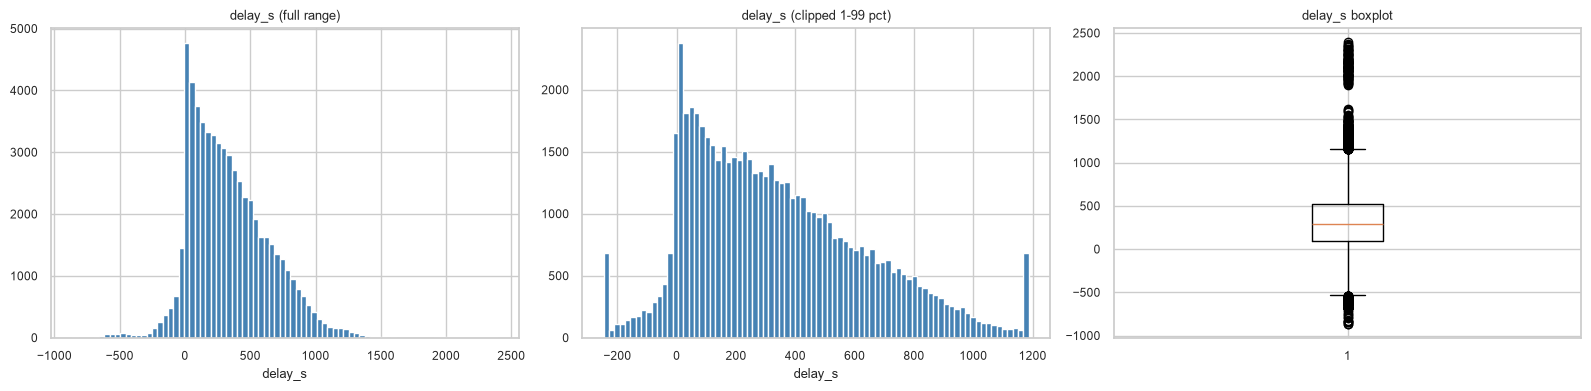


mean/median delay by hour:
       mean  median  count
hour                      
6     134.6    90.0    381
7     267.6   255.0   1507
8     287.4   267.0   2502
9     384.7   361.0   3203
10    292.0   251.0   3731
11    234.2   185.0   4800
12    301.7   282.0   7296
13    325.5   288.4   5068
14    263.1   229.0   5222
15    312.8   235.0   2963
16    441.0   362.0   6951
17    487.3   420.0   4772
18    302.8   232.0   2377
19    275.6   251.0   2731
20    417.6   384.5   4190
21    335.1   269.0   2999
22    160.9   130.0    205

mean/median delay by day:
             mean  median  count
date                            
2026-03-09  281.1   243.0  16998
2026-03-10  392.4   332.0  25032
2026-03-16  308.5   265.5  18868


In [4]:
print(df[target].describe())
print(f"\nskew: {df[target].skew():.3f}")
print(f"kurtosis: {df[target].kurtosis():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df[target], bins=80, color="steelblue")
axes[0].set_title("delay_s (full range)")
axes[0].set_xlabel("delay_s")

lo_p, hi_p = df[target].quantile([0.01, 0.99])
clipped = df[target].clip(lo_p, hi_p)
axes[1].hist(clipped, bins=80, color="steelblue")
axes[1].set_title("delay_s (clipped 1-99 pct)")
axes[1].set_xlabel("delay_s")

axes[2].boxplot(df[target], vert=True)
axes[2].set_title("delay_s boxplot")
plt.tight_layout()
plt.show()

print("\nmean/median delay by hour:")
print(df.groupby("hour")[target].agg(["mean", "median", "count"]).round(1))

print("\nmean/median delay by day:")
print(df.groupby("date")[target].agg(["mean", "median", "count"]).round(1))


## E4 — Target outliers (IQR k=3, fit on TRAIN)

**v2 rule**: drop rows outside `[lo, hi]` from **TRAIN ONLY**. Never filter test rows by their label. Rationale: extreme training values are mostly label errors from missed arrival detections (roughly one missed lap around the route); filtering test by label would flatter the reported metrics.

IQR(k=3.0) fences fit on train: lo=-1279.0s  hi=1948.0s
train outliers (dropped): 89 / 43900 (0.20%)
test outliers (kept -- v2 never filters test by label): 0 / 16998 (0.00%)


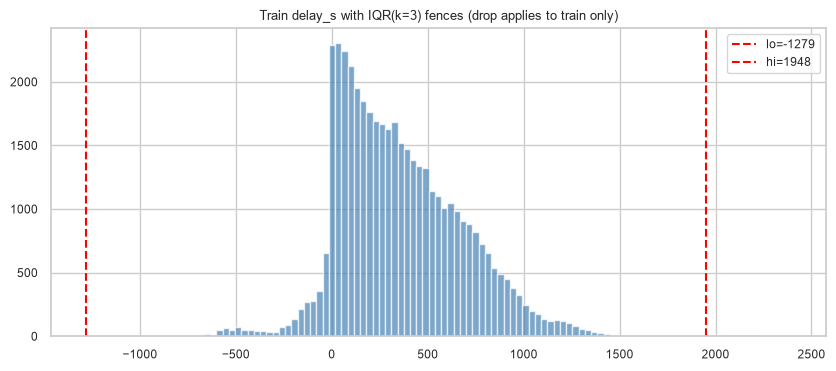


rows before: 60898  after dropping TRAIN-only target outliers: 60809  (dropped 89 train rows; kept all 16998 test rows)


In [5]:
train = df[df["split"] == "train"]
test = df[df["split"] == "test"]

lo, hi = iqr_fences(train[target], k=3.0)
print(f"IQR(k=3.0) fences fit on train: lo={lo:.1f}s  hi={hi:.1f}s")

train_out_mask = (train[target] < lo) | (train[target] > hi)
test_out_mask = (test[target] < lo) | (test[target] > hi)
train_out = int(train_out_mask.sum())
test_out = int(test_out_mask.sum())
print(f"train outliers (dropped): {train_out} / {len(train)} ({train_out/len(train):.2%})")
print(f"test outliers (kept -- v2 never filters test by label): "
      f"{test_out} / {len(test)} ({test_out/len(test):.2%})")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train[target], bins=100, color="steelblue", alpha=0.7)
ax.axvline(lo, color="red", linestyle="--", label=f"lo={lo:.0f}")
ax.axvline(hi, color="red", linestyle="--", label=f"hi={hi:.0f}")
ax.legend()
ax.set_title("Train delay_s with IQR(k=3) fences (drop applies to train only)")
plt.show()

# v2: drop outlier rows from TRAIN ONLY; keep every test row regardless of label
train_filtered = train[~train_out_mask]
df_filtered = pd.concat([train_filtered, test], ignore_index=True)
assert len(df_filtered[df_filtered["split"] == "test"]) == len(test), "must keep all test rows"
print(f"\nrows before: {len(df)}  after dropping TRAIN-only target outliers: {len(df_filtered)}  "
      f"(dropped {len(df) - len(df_filtered)} train rows; kept all {len(test)} test rows)")


## E5 — Feature outliers (report only, no dropping)

Trees are robust to outliers and the NN standardises inputs, so these are logged for awareness only. Computed on TRAIN (post target-outlier drop).

In [6]:
train_f = df_filtered[df_filtered["split"] == "train"]

rows = []
for c in features:
    lo_f, hi_f = iqr_fences(train_f[c], k=3.0)
    n_out = int(((train_f[c] < lo_f) | (train_f[c] > hi_f)).sum())
    rows.append({"feature": c, "lo": lo_f, "hi": hi_f, "n_outliers_train": n_out,
                 "pct_outliers_train": n_out / len(train_f)})
feat_outliers = pd.DataFrame(rows).sort_values("pct_outliers_train", ascending=False)
pd.set_option("display.max_rows", 60)
feat_outliers


,feature,lo,hi,n_outliers_train,pct_outliers_train
34,wx_clear,0.000000,0.000000,8940,0.204058
35,wx_cloudy,0.000000,0.000000,8526,0.194609
37,wx_rain,0.000000,0.000000,4390,0.100203
23,stop_planned_dwell_s,0.000000,0.000000,4090,0.093356
11,stationary_s,-135.003789,180.005052,3799,0.086713
32,precip_prev_1h,-0.093000,0.124000,2502,0.057109
38,wx_snow,0.000000,0.000000,1918,0.043779
1,eta_delta_s,-40.000000,30.000000,1813,0.041382
28,rain_in,-0.084000,0.112000,1507,0.034398
27,precip_in,-0.084000,0.112000,1507,0.034398


## E6 — Correlation (train, post target-outlier drop)

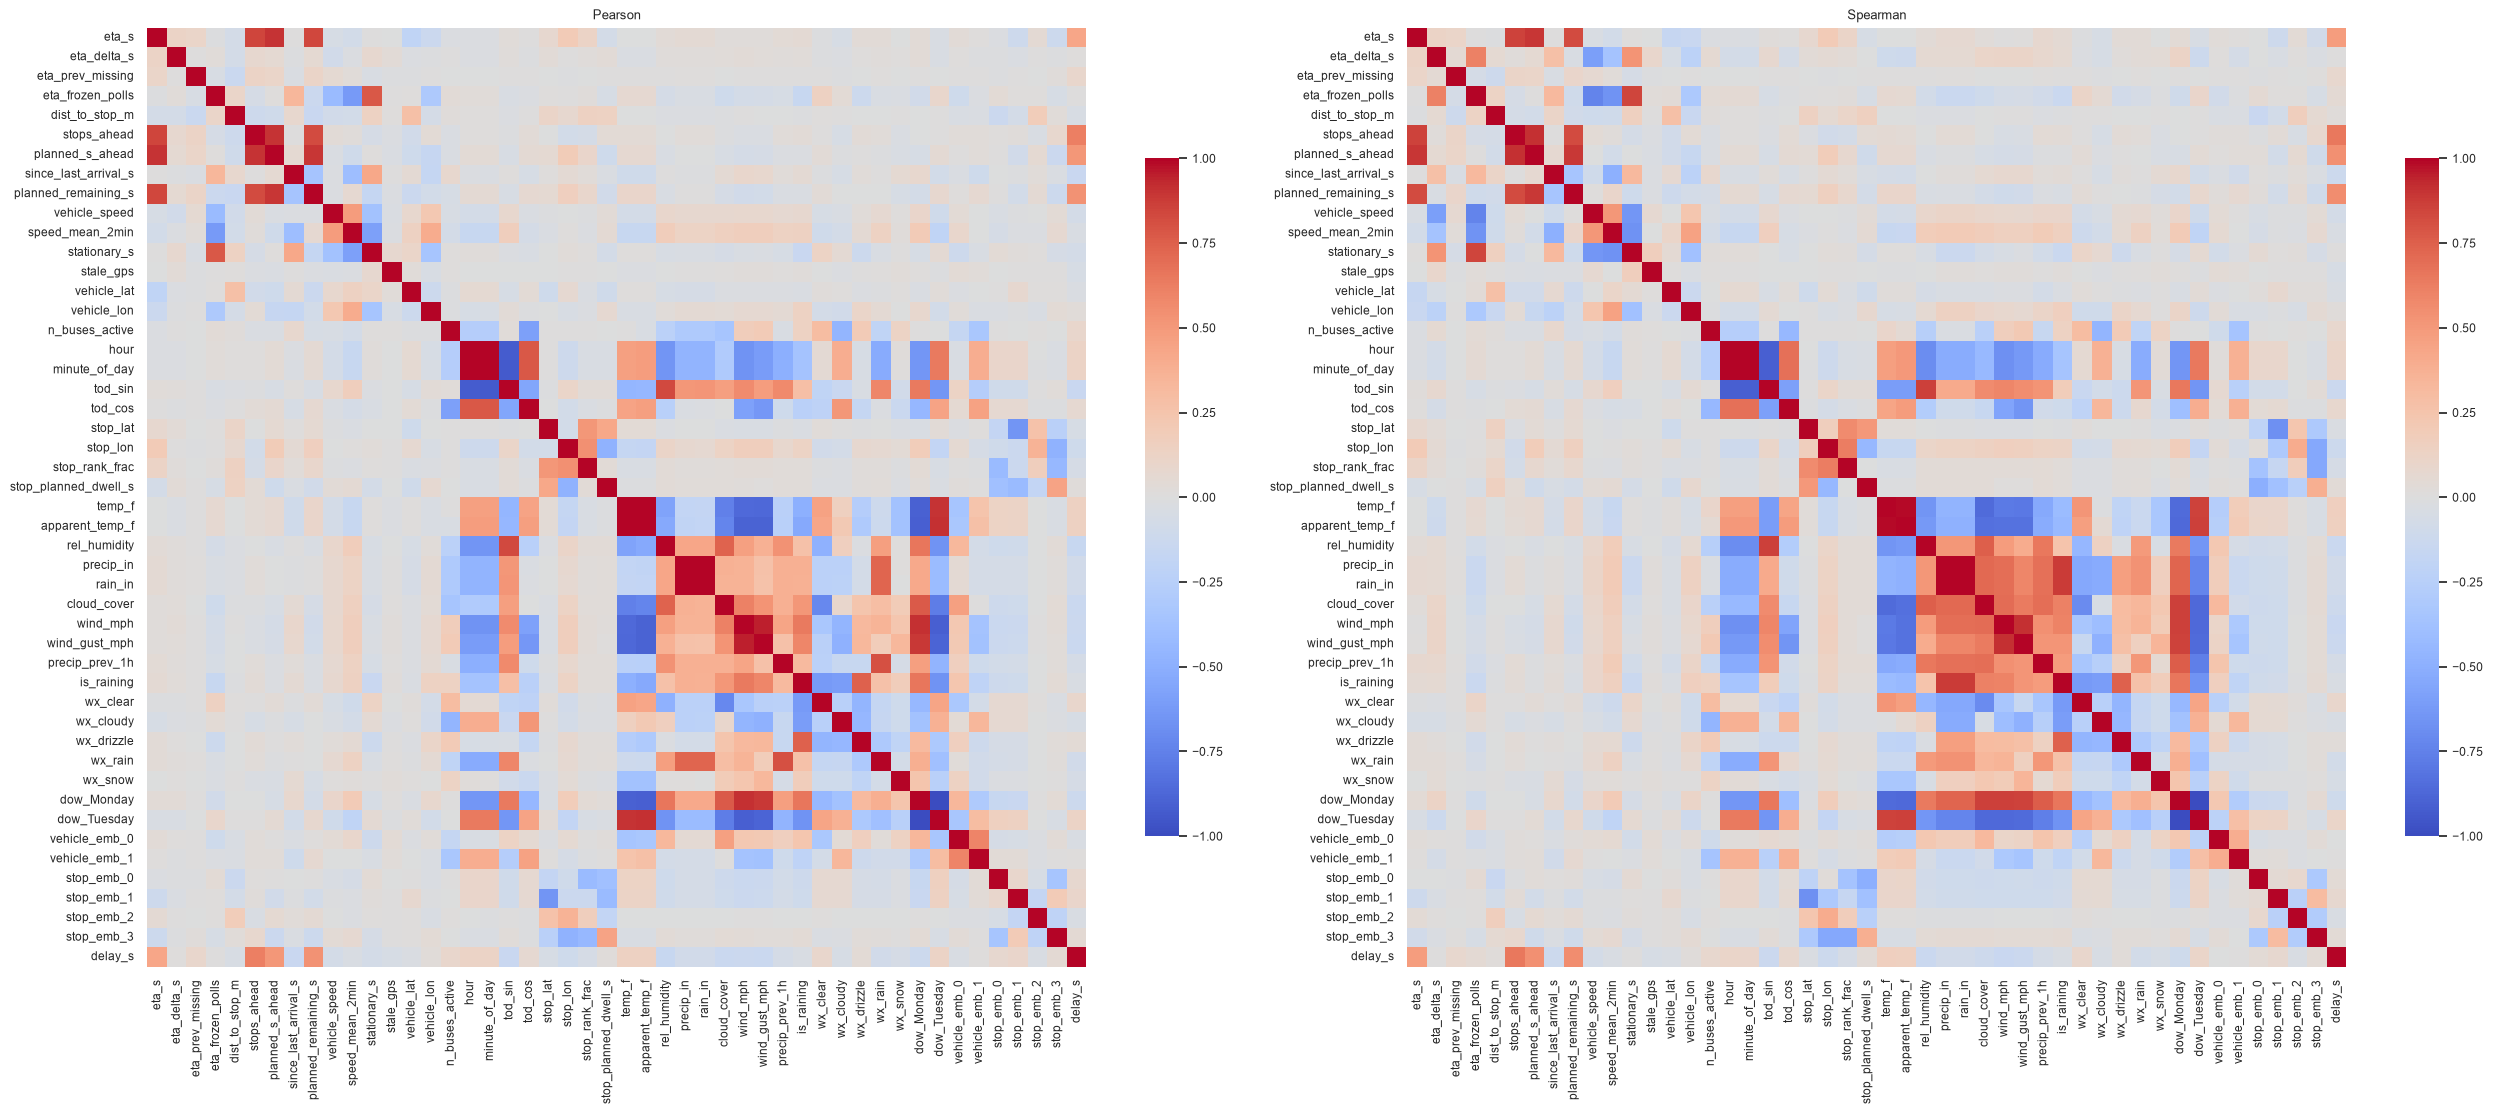

Top 15 features by |Spearman| with target:
stops_ahead             0.654
planned_remaining_s     0.556
planned_s_ahead         0.545
eta_s                   0.481
temp_f                  0.157
apparent_temp_f         0.151
wind_mph                0.144
rel_humidity            0.136
tod_sin                 0.131
wind_gust_mph           0.130
stop_lon                0.124
since_last_arrival_s    0.121
cloud_cover             0.113
hour                    0.106
dow_Monday              0.104
Name: delay_s, dtype: float64



high Spearman corr pairs (|r| >= 0.95): 4
 feature_a       feature_b  spearman
dow_Monday     dow_Tuesday -1.000000
 precip_in         rain_in  1.000000
      hour   minute_of_day  0.996909
    temp_f apparent_temp_f  0.986030

high Pearson corr pairs (|r| >= 0.95): 5
 feature_a       feature_b   pearson
dow_Monday     dow_Tuesday -1.000000
 precip_in         rain_in  0.999851
      hour   minute_of_day  0.997257
    temp_f apparent_temp_f  0.996695
  wind_mph   wind_gust_mph  0.951045


In [7]:
corr_cols = features + [target]
pearson = train_f[corr_cols].corr(method="pearson")
spearman = train_f[corr_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(26, 12))
sns.heatmap(pearson, ax=axes[0], cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            xticklabels=True, yticklabels=True, cbar_kws={"shrink": 0.6})
axes[0].set_title("Pearson")
sns.heatmap(spearman, ax=axes[1], cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            xticklabels=True, yticklabels=True, cbar_kws={"shrink": 0.6})
axes[1].set_title("Spearman")
plt.tight_layout()
plt.show()

top15 = spearman[target].drop(target).abs().sort_values(ascending=False).head(15)
print("Top 15 features by |Spearman| with target:")
print(top15.round(3))

hc_spear = high_corr_pairs(train_f, features, "spearman", 0.95)
hc_pear = high_corr_pairs(train_f, features, "pearson", 0.95)
print(f"\nhigh Spearman corr pairs (|r| >= 0.95): {len(hc_spear)}")
print(hc_spear.to_string(index=False))
print(f"\nhigh Pearson corr pairs (|r| >= 0.95): {len(hc_pear)}")
print(hc_pear.to_string(index=False))


## E7 — Correlation pruning (thresh 0.95, spearman, `eta_s` protected)

In [8]:
keep, dropped = prune_correlated(train_f, features, target, thresh=0.95, method="spearman")
print(f"kept: {len(keep)} / {len(features)}  dropped: {len(dropped)}")
assert "eta_s" in keep, "eta_s must never be dropped"
for d in dropped:
    print(d)


kept: 43 / 47  dropped: 4
{'dropped': 'rain_in', 'kept': 'precip_in', 'spearman': 1.0, 'target_corr_dropped': 0.0883, 'target_corr_kept': 0.0883}
{'dropped': 'dow_Tuesday', 'kept': 'dow_Monday', 'spearman': 1.0, 'target_corr_dropped': 0.1039, 'target_corr_kept': 0.1039}
{'dropped': 'minute_of_day', 'kept': 'hour', 'spearman': 0.9969, 'target_corr_dropped': 0.099, 'target_corr_kept': 0.1058}
{'dropped': 'apparent_temp_f', 'kept': 'temp_f', 'spearman': 0.986, 'target_corr_dropped': 0.1509, 'target_corr_kept': 0.157}


## E8 — Relationships

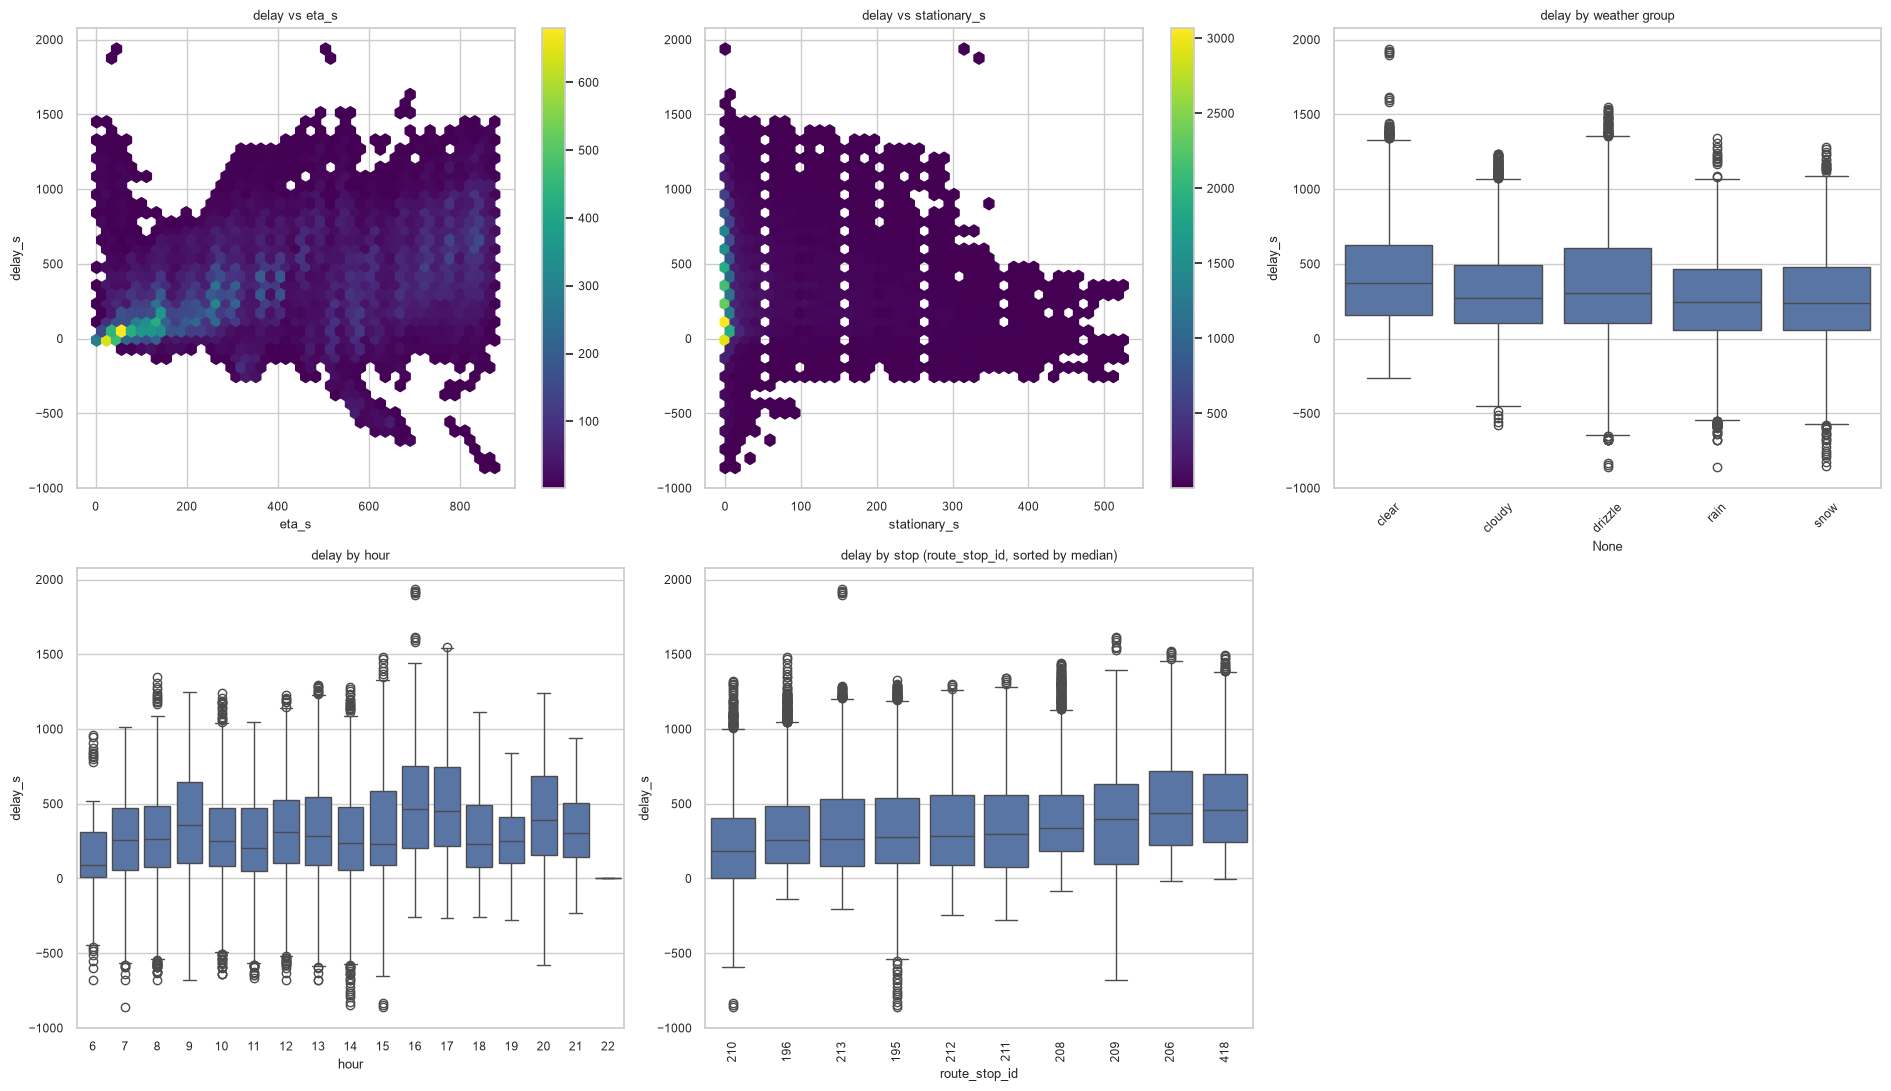

weather group counts (train):
drizzle    20037
clear       8940
cloudy      8526
rain        4390
snow        1918
Name: count, dtype: int64


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(19, 11))

hb = axes[0, 0].hexbin(train_f["eta_s"], train_f[target], gridsize=40, cmap="viridis", mincnt=1)
axes[0, 0].set_xlabel("eta_s"); axes[0, 0].set_ylabel(target); axes[0, 0].set_title("delay vs eta_s")
fig.colorbar(hb, ax=axes[0, 0])

hb2 = axes[0, 1].hexbin(train_f["stationary_s"], train_f[target], gridsize=40, cmap="viridis", mincnt=1)
axes[0, 1].set_xlabel("stationary_s"); axes[0, 1].set_title("delay vs stationary_s")
fig.colorbar(hb2, ax=axes[0, 1])

wx_cols = [c for c in features if c.startswith("wx_")]
wx_group = train_f[wx_cols].idxmax(axis=1).str.replace("wx_", "", regex=False)
sns.boxplot(x=wx_group, y=train_f[target], ax=axes[0, 2])
axes[0, 2].set_title("delay by weather group")
axes[0, 2].tick_params(axis="x", rotation=45)

sns.boxplot(x=train_f["hour"], y=train_f[target], ax=axes[1, 0])
axes[1, 0].set_title("delay by hour")

stop_order = train_f.groupby("route_stop_id")[target].median().sort_values().index
sns.boxplot(x=train_f["route_stop_id"], y=train_f[target], order=stop_order, ax=axes[1, 1])
axes[1, 1].set_title("delay by stop (route_stop_id, sorted by median)")
axes[1, 1].tick_params(axis="x", rotation=90)

axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

print("weather group counts (train):")
print(wx_group.value_counts())


## E9 — Save model-ready dataset

v2: constants are checked **within the train split** specifically (a feature could vary over the full dataset but be constant inside train alone, which still carries zero training signal), and the save must retain every test row untouched by E4's filter.

In [10]:
train_after = df_filtered[df_filtered["split"] == "train"]
newly_constant = [c for c in keep if train_after[c].nunique() <= 1]
if newly_constant:
    print(f"features that became constant WITHIN TRAIN after outlier filtering, dropping: {newly_constant}")
    keep = [c for c in keep if c not in newly_constant]
else:
    print("no features became constant within train after target-outlier filtering")

notes = {
    "split_rule": "v2: whole service day holdout (test days 2026-03-04 / 2026-03-09, whichever present)",
    "target_outlier_rule": "IQR(k=3.0) fences fit on train; rows outside dropped from TRAIN ONLY; all test rows kept regardless of label (v2 rule)",
    "target_outlier_fence_lo": lo,
    "target_outlier_fence_hi": hi,
    "target_outliers_dropped_train": train_out,
    "target_outliers_in_test_not_dropped": test_out,
    "rows_before": int(len(df)),
    "rows_after_outlier_drop": int(len(df_filtered)),
    "feature_outlier_policy": "reported only (E5), not dropped",
    "correlation_pruning_thresh": 0.95,
    "correlation_pruning_method": "spearman",
    "correlation_pruning_dropped": dropped,
    "newly_constant_within_train_after_filter": newly_constant,
    "n_features_before_pruning": len(features),
    "n_features_after_pruning": len(keep),
}

out = save_model_ready(DS, df_filtered, keep, notes=notes)
print(f"saved route_model_ready.parquet: {out.shape}")

mr = load_model_ready(DS)
n_null_reload = int(mr.df[mr.features + [mr.target]].isna().sum().sum())
const_reload_train = [c for c in mr.features if mr.X_train[c].nunique() <= 1]
print(f"reload check -> nulls: {n_null_reload}  constant-WITHIN-TRAIN features: {const_reload_train}")
assert n_null_reload == 0
assert not const_reload_train
print(f"train shape: {mr.X_train.shape}  test shape: {mr.X_test.shape}")
assert len(mr.X_train) > 0 and len(mr.X_test) > 0

test_before = int((df["split"] == "test").sum())
test_after = int((mr.df["split"] == "test").sum())
print(f"test rows in features parquet: {test_before}  test rows in model_ready: {test_after}")
assert test_after == test_before, "v2 rule: all test rows must be kept (never filtered by label)"


no features became constant within train after target-outlier filtering
saved route_model_ready.parquet: (60809, 52)


reload check -> nulls: 0  constant-WITHIN-TRAIN features: []
train shape: (43811, 43)  test shape: (16998, 43)


test rows in features parquet: 16998  test rows in model_ready: 16998


## E10 — Findings

1. **Load / quality (E1-E2).** 60,898 rows x 56 cols; 47 features, 8 meta cols, target
   `delay_s` (build now also drops stale-ETA rows: TransLoc still pointing at the stop the
   bus just passed). 0 nulls in features+target, 0 constant features, 0 duplicate rows.
   Single route (Green/17), 6 vehicles (vehicle 3 has the most rows, 23,992 -- the pick for
   the `bus` dataset), 10 stops.
2. **Split (v2, whole-day holdout).** Train = 2026-03-10 (Tue, 25,032 rows) +
   2026-03-16 (Mon, 18,868 rows) = 43,900 rows; test = 2026-03-09 (Mon, held out as a whole
   service day) = 16,998 rows (27.9% test share) -- the old date_hour-block split (found to
   leak, since labels span up to 45 min across hour boundaries) is retired. `cv_group` is now
   the **whole date** (previously date + 3-hour block): 2 train-only tuning groups
   (2026-03-10, 2026-03-16), 3 groups overall (train + test days). This is itself a
   model-selection fix -- the old within-day 3-hour blocks let a model pick up
   day-specific quirks and still score well under CV, rewarding overfitting instead of
   generalization.
3. **Target (E3).** Mean +335.3s, median +285.0s, std 310.5s, range [-862.0s, +2393.1s];
   right-skewed (skew 0.796, kurtosis 1.754). Worst on train day 2026-03-10 (mean 392.4s /
   median 332.0s); the held-out test day 2026-03-09 runs milder (mean 281.1s / median 243.0s).
   Peaks in the 16:00-17:00 rush hour (mean 441.0s / 487.3s) vs. lows at 06:00 (134.6s) and
   22:00 (160.9s).
4. **Target outliers (E4, v2 train-only rule).** IQR(k=3.0) fences fit on train:
   `[-1279.0s, 1948.0s]`. Dropped 89/43,900 train rows (0.20%). 0/16,998 test rows fall outside
   those fences -- so the "never filter test by label" rule made no difference here, but the
   rule itself still holds structurally: 60,898 -> 60,809 rows, and every dropped row is train.
5. **Feature outliers (E5, report only).** Highest train outlier rates are the one-hot
   weather flags whose IQR degenerates around the majority class (`wx_clear` 20.4%,
   `wx_cloudy` 19.5%, `wx_rain` 10.0%). Vehicle/stop entity embeddings (`vehicle_emb_0/1`,
   `stop_emb_0-3`) now show **0%** train outliers -- refitting them with a whole-day
   validation holdout removed the spread that used to make `vehicle_emb_0` the single
   highest outlier feature (37.8%). The underlying entity-count issue is unchanged: train
   sees only **4** unevenly-sized vehicle groups (vehicles 3, 5, 9, 10) -- not 6: of the 3
   vehicles the test day actually runs, 2 (13, 16) never appear in train, so both still get
   the train mean embedding, which covers 9,462/16,998 (55.7%) of test rows. Core
   trip-progress features (`eta_s`, `stops_ahead`, `planned_s_ahead`, `dist_to_stop_m`,
   speeds, coordinates) have 0% outliers.
6. **Correlation / pruning (E6-E7).** 4 of 47 features dropped at |Spearman| >= 0.95
   (43 kept): `rain_in` (dup of `precip_in`, r=1.00), `dow_Tuesday` (anti-correlated with
   `dow_Monday`, r=-1.00), `minute_of_day` (r=0.997 with `hour`), `apparent_temp_f` (r=0.986
   with `temp_f`). `eta_s` was protected and kept. Pearson additionally flags
   `wind_mph`/`wind_gust_mph` (r=0.951) but pruning here runs on Spearman only, so that pair
   stays.
7. **Strongest predictors (E6).** By |Spearman| with `delay_s` on train: `stops_ahead` (0.654),
   `planned_remaining_s` (0.556), `planned_s_ahead` (0.545), then `eta_s` itself (0.481) --
   trip progress along the route explains more rank-order variance than TransLoc's own ETA.
   Everything else (weather, time-of-day, embeddings) is weak (|r| <= 0.157, topped by
   `temp_f`).
8. **Weather coverage (E8, train post-filter).** drizzle 20,037, clear 8,940, cloudy 8,526,
   rain 4,390, snow 1,918. The day-based split keeps the rainy 2026-03-16 day entirely in
   train, so `wx_rain`/`wx_snow` carry real training signal -- but this is not a clean
   train/test match: the held-out test day (2026-03-09) has **0** `wx_rain` and **0**
   `wx_snow` rows, vs. 4,390 and 1,918 respectively in train. `rel_humidity` shows the same
   pattern in miniature: train ranges [53, 97]; 3,887/16,998 (22.9%) of test rows fall below
   the train minimum of 53.
9. **Save / verify (E9).** No feature became constant within train after the target-outlier
   drop. Saved `route_model_ready.parquet`: 60,809 rows x 43 features + target + 8 meta cols.
   Reload via `load_model_ready("route")`: 0 nulls, 0 features constant within train, train
   (43,811, 43) / test (16,998, 43), both non-empty; the test row count (16,998) matches the
   features parquet's test count exactly -- v2's "keep every test row" rule held.
